<a href="https://colab.research.google.com/github/johnsiega/Machine-Learning-Experiments/blob/main/PT_P2_NeuralNetwork_Exercices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CELL 1: Setup & Imports
**Purpose**
Mount Google Drive for file access and import all required libraries for building, training, and evaluating the Keras text classification model.

**Input**
None (environment setup)

**Output**
Mounted Drive, all libraries loaded, random seeds set for reproducibility

In [47]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from collections import Counter
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Line-by-Line Explanation**

1.   `from google.colab import drive` / `drive.mount('/content/drive')` - connects Colab to your Google Drive so the CSV dataset can be read
1.   `import pandas as pd` - for loading and handling the CSV dataset
1.   `import numpy as np` - for array/numerical operations
1.   `import tensorflow as tf` - the deep learning framework
1.   `from tensorflow.keras.models import Sequential` - the model container that stacks layers in order
1.   `from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout` - the specific layer types used in the architecture
1.   `from tensorflow.keras.optimizers import Adam, SGD` - the two optimizer options this notebook lets you switch between
1.   `from sklearn.model_selection import train_test_split` - splits data into train/val/test sets
1.   `from sklearn.metrics import f1_score, accuracy_score` - evaluation metrics beyond what Keras tracks by default
1.   `from collections import Counter` - used later to build a word frequency vocabulary
1.   `import matplotlib.pyplot as plt` - for plotting loss curves
1.   `np.random.seed(42)` / `tf.random.set_seed(42)` - fixes random number generation so results are reproducible across runs

## CELL 2: Load & Preprocess CSV Data
**Purpose**
Load the PT-P1 dataset from CSV, build a vocabulary from the text, convert each phrase into a fixed-length numeric sequence, and split the data into train/validation/test sets.

**Input**
`CSV_FILEPATH` pointing to a CSV with a text column and a label column

**Output**
`X_train, X_val, X_test, y_train, y_val, y_test` - numeric, padded, split datasets ready for the model; `vocab` - the word-to-index mapping; `num_classes` - count of distinct labels

In [5]:
CSV_FILEPATH = '/content/drive/MyDrive/NN_Training/PT-P1_Dataset.csv'
MAX_LEN = 20            # Fixed sequence length (padded/truncated)
MAX_VOCAB_SIZE = 1000   # Vocabulary size limit

# Load CSV
df = pd.read_csv(CSV_FILEPATH)

# Basic Tokenizer & Vocabulary Builder
def build_vocab(texts, max_vocab_size):
    words = [word.lower() for text in texts for word in str(text).split()]
    word_counts = Counter(words)
    # Reserve index 0 for padding (<PAD>) and 1 for unknown tokens (<UNK>)
    most_common = word_counts.most_common(max_vocab_size - 2)
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

def text_to_sequence(text, vocab, max_len):
    tokens = str(text).lower().split()
    seq = [vocab.get(token, 1) for token in tokens]
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))  # Pad with 0
    else:
        seq = seq[:max_len]                # Truncate
    return seq

# Build vocab and encode text
vocab = build_vocab(df['text'].tolist(), MAX_VOCAB_SIZE)
encoded_texts = [text_to_sequence(txt, vocab, MAX_LEN) for txt in df['text']]

X_data = np.array(encoded_texts)
y_data = np.array(df['label'].values)
num_classes = len(np.unique(y_data))

# Dataset Partitioning (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

**Line-by-Line Explanation**

1.   `CSV_FILEPATH` - path to your dataset; must be updated to point to your actual PT-P1 export, not the placeholder
1.   `MAX_LEN = 20` - every text sample is forced to exactly 20 tokens (padded with 0s if shorter, cut off if longer)
1.   `MAX_VOCAB_SIZE = 1000` - caps the vocabulary at the 1000 most common words; anything outside that becomes `<UNK>`
1.   `df = pd.read_csv(...)` - loads the dataset into a DataFrame
2.   `build_vocab()` - splits every text sample into lowercase words, counts frequency with `Counter`, keeps the most common words, and assigns each a unique integer index; reserves index `0` for padding and `1` for unknown words
2.   `text_to_sequence()` - converts one text string into a list of integers using the vocab, then pads with 0s or truncates to exactly `MAX_LEN`
2.   `vocab = build_vocab(...)` - builds the vocabulary from all training text
2.   `encoded_texts = [...]` - applies `text_to_sequence` to every row in the dataset
2.   `X_data = np.array(encoded_texts)` - converts the list of sequences into a NumPy array (the model's input)
2.   `y_data = np.array(df['label'].values)` - extracts the labels as a NumPy array
2.   `num_classes = len(np.unique(y_data))` - counts how many distinct classes exist
2.   `train_test_split(..., test_size=0.30, ...)` - splits off 30% for a combined val+test pool, keeping 70% for training
2.   `train_test_split(X_temp, y_temp, test_size=0.50, ...)` - splits that remaining 30% in half, giving 15% validation and 15% test overall

## CELL 2.1: Load & Combine Datasets (for EXP-05 Data Augmentation)
**Purpose**
Load both the PT-P1 dataset and given sample_dataset.csv, combine them into a single expanded training set, and rebuild the vocabulary/train-val-test split from this larger combined dataset.

**Input**
`CSV_FILEPATH` (PT-P1 data) and `SAMPLE_CSV_FILEPATH` (instructor's sample_dataset.csv)

**Output**
`X_train, X_val, X_test, y_train, y_val, y_test` - rebuilt from the combined, larger dataset; `vocab`, `num_classes` - also rebuilt to reflect the expanded vocabulary

In [31]:
SAMPLE_CSV_FILEPATH = '/content/drive/MyDrive/NN_Training/sample_dataset.csv'

# Load both datasets
df_ptp1 = pd.read_csv(CSV_FILEPATH)
df_sample = pd.read_csv(SAMPLE_CSV_FILEPATH)

# Keep only text/label columns from the sample dataset
df_sample = df_sample[['text', 'label']]

# Combine and shuffle
df_combined = pd.concat([df_ptp1, df_sample], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"PT-P1 rows: {len(df_ptp1)}")
print(f"Sample dataset rows: {len(df_sample)}")
print(f"Combined total rows: {len(df_combined)}")
print(f"\nClass balance after combining:")
print(df_combined['label'].value_counts().sort_index())

# Rebuild vocab and encode text using the COMBINED dataset
vocab = build_vocab(df_combined['text'].tolist(), MAX_VOCAB_SIZE)
encoded_texts = [text_to_sequence(txt, vocab, MAX_LEN) for txt in df_combined['text']]

X_data = np.array(encoded_texts)
y_data = np.array(df_combined['label'].values)
num_classes = len(np.unique(y_data))

# Re-split using the combined, larger dataset (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"\nNew training set size: {len(X_train)} (up from {int(len(df_ptp1)*0.7)} with PT-P1 alone)")

PT-P1 rows: 45
Sample dataset rows: 15
Combined total rows: 60

Class balance after combining:
label
0    20
1    20
2    20
Name: count, dtype: int64

New training set size: 42 (up from 31 with PT-P1 alone)


**Line-by-Line Explanation**

1.   `SAMPLE_CSV_FILEPATH` - path to the instructor's sample_dataset.csv, separate from your PT-P1 file
1.   `df_ptp1 = pd.read_csv(CSV_FILEPATH)` - loads your 45-row warehouse dataset
1.   `df_sample = pd.read_csv(SAMPLE_CSV_FILEPATH)` - loads the instructor's 15-row lecture-feedback dataset
1.   `df_sample = df_sample[['text', 'label']]` - drops the extra 'category' column so both DataFrames have identical structure before combining
1.   `df_combined = pd.concat([df_ptp1, df_sample], ignore_index=True)` - stacks both datasets into one; `ignore_index=True` gives it fresh sequential row numbers instead of duplicate indices
1.   `df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)` - shuffles the combined rows so PT-P1 and sample examples are mixed, not grouped in blocks (which could bias the train/val/test split if left unshuffled)
1.   `print(df_combined['label'].value_counts())` - confirms how many examples exist per class after combining, so you can check balance before training

**Everything below this point re-runs the same vocab-building and splitting logic as Cell 2, just using `df_combined` instead of `df`.**

## CELL 2.2: Reload PT-P1-Only Dataset (for EXP-05B)
**Purpose**
Revert back to the original 45-row PT-P1 dataset, undoing Cell 2.1's data expansion, so EXP-05B can isolate whether EXP-05A's strong result came from the regularization techniques or the expanded dataset.

**Input**
`CSV_FILEPATH` pointing to your PT-P1 CSV

**Output**
`X_train, X_val, X_test, y_train, y_val, y_test`, `vocab`, `num_classes` — all rebuilt from PT-P1 alone, overwriting the combined-dataset versions from Cell 2.1

In [51]:
CSV_FILEPATH = '/content/drive/MyDrive/NN_Training/PT-P1_Dataset.csv'
df_ptp1_only = pd.read_csv(CSV_FILEPATH)

vocab = build_vocab(df_ptp1_only['text'].tolist(), MAX_VOCAB_SIZE)
encoded_texts = [text_to_sequence(txt, vocab, MAX_LEN) for txt in df_ptp1_only['text']]

X_data = np.array(encoded_texts)
y_data = np.array(df_ptp1_only['label'].values)
num_classes = len(np.unique(y_data))

X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training on PT-P1 only: {len(X_train)} train samples (vs. EXP-05A's combined dataset)")

Training on PT-P1 only: 31 train samples (vs. EXP-05A's combined dataset)


**Line-by-Line Explanation**

1.   `CSV_FILEPATH` - same path used successfully in Cell 2.1, confirmed to exist
1.   `df_ptp1_only = pd.read_csv(CSV_FILEPATH)` - loads only the 45-row warehouse dataset, no sample_dataset.csv this time
1.   `vocab = build_vocab(...)` - rebuilds the vocabulary from PT-P1 text only, smaller than EXP-05A's combined vocabulary
1.   `encoded_texts = [...]` - encodes each PT-P1 row using this smaller vocab
1.   `X_data`, `y_data`, `num_classes` - rebuilt from PT-P1 alone, overwriting EXP-05A's combined-dataset versions
1.   `train_test_split(...)` (both calls) - re-splits into 70/15/15, same as Cell 2, giving you back the original ~31/7/7 sample split instead of EXP-05A's larger one

## CELL 3: Hyperparameter Configuration
**Purpose**
Define all tunable hyperparameters in one place, so each experiment (EXP-01 through EXP-05) only requires changing this dictionary rather than the model code itself.

**Input**
None - this is where values are set manually per experiment

**Output**
`CONFIG` dictionary containing this run's settings, referenced by every cell that follows

In [6]:
CONFIG = {
    "run_id": "EXP-01-KERAS-BASELINE",
    "embed_dim": 32,
    "hidden_dim": 64,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.1
}

**Line-by-Line Explanation**

1.   `run_id` - a label for this experiment, used in printed logs and plot titles so you can tell runs apart
1.   `embed_dim: 32` - Pillar 1 (Architecture): how many numbers represent each word once embedded
1.   `hidden_dim: 64` - Pillar 1 (Architecture): how many neurons are in the hidden Dense layer
1.   `learning_rate: 0.005` - Pillar 2 (Optimization): how large a step the optimizer takes when updating weights
1.   `batch_size: 32` - Pillar 2 (Optimization): how many samples are processed before each weight update
1.   `epochs: 15` - Pillar 2 (Optimization): how many full passes through the training data
1.   `optimizer_type: "Adam"` - Pillar 2 (Optimization): which optimizer algorithm to use (Adam or SGD)
1.   `dropout_rate: 0.1` - Pillar 3 (Regularization): fraction of neurons randomly disabled each training step, to reduce overfitting

## CELL 3.1: Hyperparameter Configuration — EXP-02 (Induce Underfitting)
**Purpose**
Configure a deliberately weak model — low learning rate and low hidden capacity — to demonstrate underfitting, per Task 2's required experiment table.

**Input**
None - this is where values are set manually per experiment

**Output**
`CONFIG` dictionary for EXP-02, used by the architecture/training cells that follow it

In [13]:
CONFIG = {
    "run_id": "EXP-02-LOW-CAPACITY-UNDERFIT",
    "embed_dim": 32,
    "hidden_dim": 16,
    "learning_rate": 0.0001,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.0
}

**Line-by-Line Explanation**

1.   `run_id: "EXP-02-LOW-CAPACITY-UNDERFIT"` - labels this run distinctly from EXP-01 in logs and plot titles
1.   `embed_dim: 32` - unchanged from baseline, so this run isolates the effect of learning rate + hidden capacity only
1.   `hidden_dim: 16` - drastically reduced from EXP-01's 64; a smaller hidden layer has less capacity to learn complex patterns
1.   `learning_rate: 0.0001` - 50x smaller than EXP-01's 0.005; the optimizer takes much tinier steps, so weights barely update within 15 epochs
1.   `batch_size: 32` - unchanged, per the instructions' experiment table
1.   `epochs: 15` - unchanged, so this stays a fair comparison against EXP-01
1.   `optimizer_type: "Adam"` - unchanged
1.   `dropout_rate: 0.0` - no regularization applied here, since the goal is to isolate underfitting, not test dropout

**Why this should underfit:** low hidden_dim limits how much the model *can* represent, and a tiny learning rate limits how much it *can* learn in the given epochs — both training and validation loss should stay high and barely move, unlike EXP-01 where training loss dropped sharply.

## CELL 3.2: Hyperparameter Configuration — EXP-03 (Induce Overfitting)
**Purpose**
Configure a deliberately high-capacity model with no regularization and an aggressive learning rate, to demonstrate overfitting under extreme conditions, per Task 2's required experiment table.

**Input**
None - this is where values are set manually per experiment

**Output**
`CONFIG` dictionary for EXP-03, used by the architecture/training cells that follow it

In [19]:
CONFIG = {
    "run_id": "EXP-03-HIGH-CAPACITY-OVERFIT",
    "embed_dim": 32,
    "hidden_dim": 256,
    "learning_rate": 0.05,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.0
}

**Line-by-Line Explanation**

1.   `run_id: "EXP-03-HIGH-CAPACITY-OVERFIT"` - labels this run distinctly in logs and plot titles
1.   `embed_dim: 32` - unchanged from EXP-01, isolates the effect of hidden_dim, learning_rate, and dropout
1.   `hidden_dim: 256` - 4x larger than EXP-01's 64, giving the model far more capacity to memorize patterns, including noise
1.   `learning_rate: 0.05` - 10x larger than EXP-01's 0.005; large steps can cause the model to fit training data very quickly, sometimes erratically
1.   `batch_size: 32` - unchanged, per the instructions' experiment table
1.   `epochs: 15` - unchanged, so this stays comparable to EXP-01 and EXP-02
1.   `optimizer_type: "Adam"` - unchanged
1.   `dropout_rate: 0.0` - no regularization at all; this is the key condition that should let the model overfit unchecked

**Why this should overfit more severely than EXP-01:** EXP-01 already overfit with hidden_dim=64. Quadrupling capacity to 256 with zero dropout and a much larger learning rate should make the model memorize training data even faster and more completely, likely widening the training/validation loss gap even further than EXP-01's.

## CELL 3.3: Hyperparameter Configuration — EXP-04 (Regularized High Capacity)
**Purpose**
Configure a high-capacity model with dropout enabled, to test whether regularization resolves the overfitting seen in EXP-03.

**Input**
None - this is where values are set manually per experiment

**Output**
`CONFIG` dictionary for EXP-04, used by the architecture/training cells that follow it

In [25]:
CONFIG = {
    "run_id": "EXP-04-REGULARIZED-HIGH-CAPACITY",
    "embed_dim": 32,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.4
}

**Line-by-Line Explanation**

1.   `run_id: "EXP-04-REGULARIZED-HIGH-CAPACITY"` - labels this run distinctly in logs and plot titles
1.   `embed_dim: 32` - unchanged from all prior runs
1.   `hidden_dim: 128` - between EXP-01's 64 and EXP-03's 256; still high capacity, but not as extreme as EXP-03
1.   `learning_rate: 0.005` - back to the EXP-01 baseline rate, not EXP-03's aggressive 0.05, isolating dropout as the main variable being tested
1.   `batch_size: 32` - unchanged
1.   `epochs: 15` - unchanged
1.   `optimizer_type: "Adam"` - unchanged
1.   `dropout_rate: 0.4` - the key change from EXP-03: 40% of neurons randomly disabled each training step, directly countering the memorization seen in EXP-03

**Why this should reduce overfitting:** dropout forces the network to not rely on any single neuron's memorized pattern, pushing it toward more redundant, generalizable representations - the validation loss curve should stay much closer to the training loss curve than EXP-03's did.

## CELL 3.4: Hyperparameter Configuration — EXP-05A (Early Stopping + L2 Regularization)
**Purpose**
Configure a run that combines the best-performing architecture so far (EXP-04's regularized high capacity) with two techniques not yet tested: Early Stopping and L2 weight decay, using the expanded combined dataset from Cell 2.1.

**Input**
None - this is where values are set manually per experiment

**Output**
`CONFIG` dictionary for EXP-05A, plus two new settings (`l2_lambda`, `early_stop_patience`) used by the architecture and training cells that follow it

In [35]:
CONFIG = {
    "run_id": "EXP-05A-EARLYSTOP-L2",
    "embed_dim": 32,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 30,
    "optimizer_type": "Adam",
    "dropout_rate": 0.4,
    "l2_lambda": 0.01,
    "early_stop_patience": 3
}

**Line-by-Line Explanation**

1.   `run_id: "EXP-05A-EARLYSTOP-L2"` - labels this run distinctly in logs and plot titles
1.   `embed_dim: 32` - unchanged from all prior runs
1.   `hidden_dim: 128` - carried over from EXP-04, the best-performing config so far
1.   `learning_rate: 0.005` - carried over from EXP-04's baseline rate
1.   `batch_size: 32` - unchanged
1.   `epochs: 30` - increased from 15, since Early Stopping will now decide when to actually stop, rather than a fixed count - this gives it room to find that point
1.   `optimizer_type: "Adam"` - unchanged
1.   `dropout_rate: 0.4` - carried over from EXP-04
1.   `l2_lambda: 0.01` - new: strength of the L2 weight decay penalty added to the hidden layer, discourages any single weight from growing too large
1.   `early_stop_patience: 3` - new: how many epochs of no improvement in validation loss to tolerate before stopping training early

**Why combine these two techniques:** dropout alone (EXP-04) only partially controlled overfitting. L2 regularization attacks the problem from a different angle (penalizing large weights directly in the loss function, rather than randomly dropping neurons), and Early Stopping prevents wasting epochs training past the point where validation loss stops improving - together they're testing whether code-based fine control (unavailable in the no-code tool) can finally beat the PT-P1 benchmark.

## CELL 3.5: Hyperparameter Configuration — EXP-05B (Same Regularization, PT-P1 Only)
**Purpose**
Configure the identical regularization setup as EXP-05A (L2 + dropout + Early Stopping), but this run will train on PT-P1-only data (from Cell 2.2) instead of the expanded combined dataset.

**Input**
None - this is where values are set manually per experiment

**Output**
`CONFIG` dictionary for EXP-05B, identical values to EXP-05A except run_id

In [52]:
CONFIG = {
    "run_id": "EXP-05B-EARLYSTOP-L2-PTP1ONLY",
    "embed_dim": 32,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 30,
    "optimizer_type": "Adam",
    "dropout_rate": 0.4,
    "l2_lambda": 0.01,
    "early_stop_patience": 3
}

**Line-by-Line Explanation**

1.   `run_id: "EXP-05B-EARLYSTOP-L2-PTP1ONLY"` - labels this run distinctly; note every other value is intentionally identical to EXP-05A
1.   `hidden_dim: 128`, `learning_rate: 0.005`, `dropout_rate: 0.4`, `l2_lambda: 0.01`, `early_stop_patience: 3` - all unchanged from EXP-05A, since the only variable being tested here is the dataset (Cell 2.2's PT-P1-only vs. Cell 2.1's combined data)
1.   `epochs: 30` - same ceiling as EXP-05A, Early Stopping will decide the actual stopping point

**Why keep everything else identical:** this is a controlled experiment - if only the dataset changes and every hyperparameter stays the same, any difference in final F1-score between EXP-05A and EXP-05B can be attributed specifically to the data expansion, not to some other confounding change.

## CELL 4: Keras Sequential Architecture
**Purpose**
Build the neural network layer by layer, defining how raw token sequences are transformed into a final class prediction.

**Input**
`vocab`, `MAX_LEN`, `num_classes`, and `CONFIG` values

**Output**
`model` - an uncompiled Keras Sequential model with all layers stacked

In [7]:
model = Sequential()

# Embedding Layer (Pillar 1: Architecture)
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))

# Global Average Pooling across token sequence dimension
model.add(GlobalAveragePooling1D())

# First Hidden Layer
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))

# Regularization Layer (Pillar 3: Regularization)
model.add(Dropout(CONFIG["dropout_rate"]))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**Line-by-Line Explanation**

1.   `model = Sequential()` - creates an empty model that layers will be added to in order
1.   `Embedding(...)` - this is where feature extraction begins; converts each word's integer index into a learnable dense vector of size `embed_dim`; `mask_zero=True` tells the model to ignore padding tokens
1.   `GlobalAveragePooling1D()` - averages all the word vectors in a sequence into one fixed-length vector, regardless of sentence length; condenses variable-length text into something the Dense layers can classify
1.   `Dense(CONFIG["hidden_dim"], activation='relu')` - the hidden layer that learns combinations of the pooled features; ReLU introduces non-linearity
1.   `Dropout(CONFIG["dropout_rate"])` - randomly zeroes out a fraction of neurons during training only, forcing the network not to over-rely on any single feature
1.   `Dense(num_classes, activation='softmax')` - the output layer; produces one probability per class, all summing to 1

## CELL 4.1: Keras Sequential Architecture — EXP-02
**Purpose**
Build the low-capacity model architecture for EXP-02, using the reduced hidden_dim from CONFIG (Cell 3.1).

**Input**
`vocab`, `MAX_LEN`, `num_classes` (from Cell 2), and `CONFIG` (from Cell 3.1)

**Output**
`model` - an uncompiled Keras Sequential model built with EXP-02's smaller architecture

In [14]:
model = Sequential()

# Embedding Layer (Pillar 1: Architecture)
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))

# Global Average Pooling across token sequence dimension
model.add(GlobalAveragePooling1D())

# First Hidden Layer (reduced capacity for EXP-02)
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))

# Regularization Layer (Pillar 3: Regularization) - disabled this run
model.add(Dropout(CONFIG["dropout_rate"]))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**Line-by-Line Explanation**

1.   `model = Sequential()` - creates a new empty model for this run
1.   `Embedding(...)` - same structure as EXP-01; converts word indices into dense vectors of size `embed_dim` (unchanged at 32)
1.   `GlobalAveragePooling1D()` - condenses the sequence into one fixed-length vector, same as EXP-01
1.   `Dense(CONFIG["hidden_dim"], activation='relu')` - this is the key change from EXP-01: only 16 neurons instead of 64, drastically reducing the model's capacity to learn complex patterns
1.   `Dropout(CONFIG["dropout_rate"])` - set to 0.0 this run, so effectively does nothing; included for structural consistency with EXP-01
1.   `Dense(num_classes, activation='softmax')` - output layer, unchanged

## CELL 4.2: Keras Sequential Architecture — EXP-03
**Purpose**
Build the high-capacity, zero-regularization model architecture for EXP-03.

**Input**
`vocab`, `MAX_LEN`, `num_classes` (from Cell 2), and `CONFIG` (from Cell 3.2)

**Output**
`model` - an uncompiled Keras Sequential model built with EXP-03's large architecture

In [20]:
model = Sequential()

# Embedding Layer (Pillar 1: Architecture)
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))

# Global Average Pooling across token sequence dimension
model.add(GlobalAveragePooling1D())

# First Hidden Layer (high capacity for EXP-03)
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))

# Regularization Layer (Pillar 3: Regularization) - disabled this run
model.add(Dropout(CONFIG["dropout_rate"]))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**Line-by-Line Explanation**

1.   `model = Sequential()` - creates a new empty model for this run
1.   `Embedding(...)` - same structure as prior runs; converts word indices into dense vectors (embed_dim unchanged at 32)
1.   `GlobalAveragePooling1D()` - condenses the sequence into a fixed-length vector, unchanged
1.   `Dense(CONFIG["hidden_dim"], activation='relu')` - key change: 256 neurons instead of 64, giving the model significantly more parameters to memorize training examples with
1.   `Dropout(CONFIG["dropout_rate"])` - set to 0.0, meaning this layer does nothing this run - deliberately removing the one mechanism that could counteract overfitting
1.   `Dense(num_classes, activation='softmax')` - output layer, unchanged

## CELL 4.3: Keras Sequential Architecture — EXP-04
**Purpose**
Build the regularized high-capacity model architecture for EXP-04.

**Input**
`vocab`, `MAX_LEN`, `num_classes` (from Cell 2), and `CONFIG` (from Cell 3.3)

**Output**
`model` - an uncompiled Keras Sequential model with 128 hidden units and 0.4 dropout

In [26]:
model = Sequential()

# Embedding Layer (Pillar 1: Architecture)
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))

# Global Average Pooling across token sequence dimension
model.add(GlobalAveragePooling1D())

# First Hidden Layer (moderate-high capacity for EXP-04)
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))

# Regularization Layer (Pillar 3: Regularization) - active this run
model.add(Dropout(CONFIG["dropout_rate"]))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**Line-by-Line Explanation**

1.   `model = Sequential()` - creates a new empty model for this run
1.   `Embedding(...)` - unchanged structure, embed_dim still 32
1.   `GlobalAveragePooling1D()` - unchanged
1.   `Dense(CONFIG["hidden_dim"], activation='relu')` - 128 neurons, moderate-high capacity
1.   `Dropout(CONFIG["dropout_rate"])` - now active at 0.4, unlike EXP-03's 0.0 - this is the critical difference being tested
1.   `Dense(num_classes, activation='softmax')` - output layer, unchanged

## CELL 4.4: Keras Sequential Architecture — EXP-05A (with L2 Regularization)
**Purpose**
Build the EXP-05A model architecture, adding an L2 weight decay penalty to the hidden Dense layer on top of the existing dropout.

**Input**
`vocab`, `MAX_LEN`, `num_classes` (from Cell 2.1), and `CONFIG` (from Cell 3.4)

**Output**
`model` - an uncompiled Keras Sequential model with both dropout and L2 regularization active

In [36]:
from tensorflow.keras.regularizers import l2

model = Sequential()

# Embedding Layer (Pillar 1: Architecture)
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))

# Global Average Pooling across token sequence dimension
model.add(GlobalAveragePooling1D())

# First Hidden Layer with L2 weight decay (Pillar 1 + new regularization technique)
model.add(Dense(CONFIG["hidden_dim"], activation='relu', kernel_regularizer=l2(CONFIG["l2_lambda"])))

# Regularization Layer (Pillar 3: Regularization) - dropout still active
model.add(Dropout(CONFIG["dropout_rate"]))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

**Line-by-Line Explanation**

1.   `from tensorflow.keras.regularizers import l2` - imports the L2 penalty function, not used in any prior experiment
1.   `model = Sequential()` - creates a new empty model for this run
1.   `Embedding(...)` - unchanged structure, embed_dim still 32
1.   `GlobalAveragePooling1D()` - unchanged
1.   `Dense(CONFIG["hidden_dim"], activation='relu', kernel_regularizer=l2(CONFIG["l2_lambda"]))` - the key addition: `kernel_regularizer=l2(...)` adds a penalty term to the loss based on the size of this layer's weights, discouraging any single weight from growing too large - this is a second, independent regularization mechanism alongside dropout
1.   `Dropout(CONFIG["dropout_rate"])` - unchanged from EXP-04, still active at 0.4
1.   `Dense(num_classes, activation='softmax')` - output layer, unchanged

## CELL 4.5: Keras Sequential Architecture — EXP-05B
**Purpose**
Build the identical architecture to EXP-05A (with L2 regularization), now to be trained on the PT-P1-only dataset.

**Input**
`vocab`, `MAX_LEN`, `num_classes` (from Cell 2.2), and `CONFIG` (from Cell 3.5)

**Output**
`model` - an uncompiled Keras Sequential model, same structure as EXP-05A

In [55]:
model = Sequential()

# Embedding Layer (Pillar 1: Architecture)
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))

# Global Average Pooling across token sequence dimension
model.add(GlobalAveragePooling1D())

# First Hidden Layer with L2 weight decay
model.add(Dense(CONFIG["hidden_dim"], activation='relu', kernel_regularizer=l2(CONFIG["l2_lambda"])))

# Regularization Layer (Pillar 3: Regularization)
model.add(Dropout(CONFIG["dropout_rate"]))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

**Line-by-Line Explanation**

1.   `model = Sequential()` - creates a new empty model for this run
1.   `Embedding(...)` - uses `vocab` from Cell 2.2, which is smaller than EXP-05A's combined vocab, since it's built only from PT-P1 text
1.   `GlobalAveragePooling1D()` - unchanged
1.   `Dense(CONFIG["hidden_dim"], activation='relu', kernel_regularizer=l2(CONFIG["l2_lambda"]))` - same L2 regularization as EXP-05A
1.   `Dropout(CONFIG["dropout_rate"])` - same 0.4 dropout as EXP-05A
1.   `Dense(num_classes, activation='softmax')` - output layer, unchanged

## CELL 5: Optimizer & Compilation
**Purpose**
Choose the optimizer algorithm, attach the loss function, and finalize the model so it's ready to train.

**Input**
`model` from Cell 4, `CONFIG` values

**Output**
A compiled model, plus a printed architecture summary

In [8]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

# Configure loss function, optimizer engine, and evaluation metrics
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**

1.   `if CONFIG["optimizer_type"] == "Adam": opt = Adam(...)` / `else: opt = SGD(...)` - selects which optimizer object to build, based on the config
2.   `model.compile(...)` - locks in three things the model needs before training:
     *   `loss='sparse_categorical_crossentropy'` - the function that measures how wrong each prediction is; "sparse" means labels are plain integers rather than one-hot vectors
     *   `optimizer=opt` - the algorithm (Adam or SGD) that will use the loss to update weights
     *   `metrics=['accuracy']` - tracks accuracy alongside loss during training, for readability
2.   `model.summary()` - prints a table of every layer, its output shape, and its parameter count, useful for sanity-checking the architecture before training

## CELL 5.1: Optimizer & Compilation — EXP-02
**Purpose**
Attach the very small learning rate to the Adam optimizer and compile the EXP-02 model.

**Input**
`model` from Cell 4.1, `CONFIG` from Cell 3.1

**Output**
A compiled model, plus a printed architecture summary

In [15]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

# Configure loss function, optimizer engine, and evaluation metrics
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**

1.   `if CONFIG["optimizer_type"] == "Adam": opt = Adam(...)` - builds an Adam optimizer, but this time with `learning_rate=0.0001` instead of EXP-01's 0.005 - a 50x smaller step size
1.   `model.compile(...)` - locks in the loss function, optimizer, and tracked metrics, identical setup to EXP-01 so the comparison is fair
1.   `model.summary()` - prints the layer table; the parameter count here will be lower than EXP-01's since hidden_dim dropped from 64 to 16

## CELL 5.2: Optimizer & Compilation — EXP-03
**Purpose**
Attach the aggressive learning rate to the Adam optimizer and compile the EXP-03 model.

**Input**
`model` from Cell 4.2, `CONFIG` from Cell 3.2

**Output**
A compiled model, plus a printed architecture summary

In [21]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

# Configure loss function, optimizer engine, and evaluation metrics
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**

1.   `if CONFIG["optimizer_type"] == "Adam": opt = Adam(...)` - builds an Adam optimizer with `learning_rate=0.05`, 10x larger than EXP-01's 0.005
1.   `model.compile(...)` - identical loss/metrics setup to prior runs, so the comparison stays fair
1.   `model.summary()` - prints the layer table; parameter count here should be noticeably higher than EXP-01 and EXP-02, since hidden_dim jumped to 256

## CELL 5.3: Optimizer & Compilation — EXP-04
**Purpose**
Attach the baseline learning rate to Adam and compile the EXP-04 model.

**Input**
`model` from Cell 4.3, `CONFIG` from Cell 3.3

**Output**
A compiled model, plus a printed architecture summary

In [27]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

# Configure loss function, optimizer engine, and evaluation metrics
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## CELL 5.3: Optimizer & Compilation — EXP-04
**Purpose**
Attach the baseline learning rate to Adam and compile the EXP-04 model.

**Input**
`model` from Cell 4.3, `CONFIG` from Cell 3.3

**Output**
A compiled model, plus a printed architecture summary

## CELL 5.4: Optimizer & Compilation — EXP-05A
**Purpose**
Attach the optimizer and compile the EXP-05A model, identical to prior runs.

**Input**
`model` from Cell 4.4, `CONFIG` from Cell 3.4

**Output**
A compiled model, plus a printed architecture summary

In [38]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

# Configure loss function, optimizer engine, and evaluation metrics
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**

1.   `if CONFIG["optimizer_type"] == "Adam": opt = Adam(...)` - builds Adam with `learning_rate=0.005`, same as EXP-04
1.   `model.compile(...)` - identical loss/metrics setup to all prior runs; the L2 penalty from Cell 4.4 gets automatically added into the total loss during training, no extra step needed here
1.   `model.summary()` - prints the layer table; parameter count matches EXP-04's, since L2 doesn't add new parameters, just a penalty term

## CELL 5.5: Optimizer & Compilation — EXP-05B
**Purpose**
Attach the optimizer and compile the EXP-05B model, identical setup to EXP-05A.

**Input**
`model` from Cell 4.5, `CONFIG` from Cell 3.5

**Output**
A compiled model, plus a printed architecture summary

In [56]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**

1.   `if CONFIG["optimizer_type"] == "Adam": opt = Adam(...)` - builds Adam with `learning_rate=0.005`, same as EXP-05A
1.   `model.compile(...)` - identical loss/metrics setup to EXP-05A
1.   `model.summary()` - parameter count may differ slightly from EXP-05A's, since the Embedding layer's size depends on vocab size, which is smaller here (PT-P1-only vocab vs. combined vocab)

## CELL 6: The Operational Loop (Fit & Evaluate)
**Purpose**
Train the model on the training set while monitoring performance on the validation set, then compute final F1-score on validation data.

**Input**
`X_train, y_train, X_val, y_val`, compiled `model`, `CONFIG`

**Output**
`history` - a record of loss/accuracy per epoch; `val_f1`, `val_loss` - final validation metrics; printed log line summarizing the run

In [9]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Compute final validation predictions for F1-Score calculation
val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

# Final Log Output summary for Excel logging
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

--- Starting Training Run: EXP-01-KERAS-BASELINE ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2903 - loss: 1.1001 - val_accuracy: 0.2857 - val_loss: 1.1027
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4839 - loss: 1.0894 - val_accuracy: 0.2857 - val_loss: 1.1044
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4516 - loss: 1.0795 - val_accuracy: 0.2857 - val_loss: 1.1059
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6129 - loss: 1.0662 - val_accuracy: 0.2857 - val_loss: 1.1079
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6129 - loss: 1.0508 - val_accuracy: 0.2857 - val_loss: 1.1102
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7097 - loss: 1.0294 - val_accuracy: 0.2857 - val_loss: 1.1128
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9355 - loss: 1.0069 - val_accuracy: 0.2857 - val_loss: 1.1158
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9355 - loss

**Line-by-Line Explanation**

1.   `model.fit(...)` - this is where the Forward Pass (compute predictions and loss) and Backward Pass (compute gradients and update weights via the optimizer) actually happen, once per batch, for every epoch; Keras handles both automatically, they aren't written out as separate visible steps
1.   `validation_data=(X_val, y_val)` - after each epoch, the model evaluates itself on unseen validation data, without training on it - this is what produces the val_loss/val_accuracy curves
1.   `epochs=CONFIG["epochs"]` - number of full training passes
1.   `batch_size=CONFIG["batch_size"]` - samples per weight update
2.   `history.history` - a dictionary Keras automatically fills with `loss`, `accuracy`, `val_loss`, `val_accuracy` per epoch
2.   `model.predict(X_val)` - runs the trained model on validation data to get class probabilities
2.   `np.argmax(val_preds_probs, axis=1)` - converts probabilities into a single predicted class per sample (the class with highest probability)
2.   `f1_score(y_val, val_preds, average='weighted')` - computes F1-score, weighted by how many samples are in each class (accounts for class imbalance)
2.   `history.history['val_loss'][-1]` - grabs the final epoch's validation loss
2.   Final print statement - outputs a one-line summary formatted for easy copying into your experiment log spreadsheet

## CELL 6.1: The Operational Loop (Fit & Evaluate) — EXP-02
**Purpose**
Train the low-capacity, low-learning-rate model and check whether it underfits as expected.

**Input**
`X_train, y_train, X_val, y_val` (from Cell 2), compiled `model` (from Cell 5.1), `CONFIG` (from Cell 3.1)

**Output**
`history` - per-epoch training record; `val_f1`, `val_loss` - final validation metrics; printed EXP-02 log line

In [16]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Compute final validation predictions for F1-Score calculation
val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

# Final Log Output summary for Excel logging
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

--- Starting Training Run: EXP-02-LOW-CAPACITY-UNDERFIT ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3226 - loss: 1.0997 - val_accuracy: 0.1429 - val_loss: 1.1005
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3548 - loss: 1.0993 - val_accuracy: 0.1429 - val_loss: 1.1005
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3871 - loss: 1.0990 - val_accuracy: 0.1429 - val_loss: 1.1004
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4839 - loss: 1.0986 - val_accuracy: 0.1429 - val_loss: 1.1004
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4839 - loss: 1.0983 - val_accuracy: 0.1429 - val_loss: 1.1004
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4839 - loss: 1.0979 - val_accuracy: 0.1429 - val_loss: 1.1004
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5161 - loss: 1.0976 - val_accuracy: 0.1429 - val_loss: 1.1004
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.580

**Line-by-Line Explanation**

1.   `model.fit(...)` - runs forward and backward passes each epoch; with such a small learning_rate, weight updates should be tiny each step
1.   `validation_data=(X_val, y_val)` - tracks validation loss/accuracy alongside training, same as EXP-01
1.   **What to expect if this underfits correctly:** both training loss and validation loss should stay high and barely decrease across all 15 epochs, unlike EXP-01 where training loss dropped sharply - this is the visual signature of underfitting
1.   `model.predict(X_val)` / `np.argmax(...)` - converts predicted probabilities into class labels
1.   `f1_score(y_val, val_preds, average='weighted')` - computes weighted F1 for this run
1.   Final print statement - logs EXP-02's results in the same format as EXP-01, for direct comparison in your spreadsheet

## CELL 6.2: The Operational Loop (Fit & Evaluate) — EXP-03
**Purpose**
Train the high-capacity, zero-regularization, aggressive-learning-rate model and check whether it overfits more severely than EXP-01.

**Input**
`X_train, y_train, X_val, y_val` (from Cell 2), compiled `model` (from Cell 5.2), `CONFIG` (from Cell 3.2)

**Output**
`history` - per-epoch training record; `val_f1`, `val_loss` - final validation metrics; printed EXP-03 log line

In [22]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Compute final validation predictions for F1-Score calculation
val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

# Final Log Output summary for Excel logging
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

--- Starting Training Run: EXP-03-HIGH-CAPACITY-OVERFIT ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2903 - loss: 1.0978 - val_accuracy: 0.2857 - val_loss: 1.1028
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6452 - loss: 0.9631 - val_accuracy: 0.1429 - val_loss: 1.1343
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 1.0000 - loss: 0.4078 - val_accuracy: 0.1429 - val_loss: 1.3584
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 0.0817 - val_accuracy: 0.2857 - val_loss: 1.9112
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.2857 - val_loss: 2.7299
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 1.0000 - loss: 6.9501e-05 - val_accuracy: 0.2857 - val_loss: 3.7297
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 4.1146e-07 - val_accuracy: 0.2857 - val_loss: 4.8347
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - ac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step

=== EXP LOG ENTRY ===
ID: EXP-03-HIGH-CAPACITY-OVERFIT | LR: 0.05 | Hidden: 256 | Dropout: 0.0 | Final Val Loss: 14.0840 | Final Val F1: 0.1633


**Line-by-Line Explanation**

1.   `model.fit(...)` - runs forward and backward passes each epoch; with a large learning_rate and huge capacity, training loss should fall very fast, likely faster than EXP-01
1.   `validation_data=(X_val, y_val)` - tracks validation loss/accuracy alongside training
1.   **What to expect if this overfits as intended:** training loss should drop sharply (possibly even faster/more erratically than EXP-01 due to the larger learning rate), while validation loss should rise or stay flat - watch for instability too, since a learning rate this large can sometimes cause loss to spike or oscillate rather than decrease smoothly
1.   `model.predict(X_val)` / `np.argmax(...)` - converts predicted probabilities into class labels
1.   `f1_score(y_val, val_preds, average='weighted')` - computes weighted F1 for this run
1.   Final print statement - logs EXP-03's results in the same format as prior runs, for direct comparison in your spreadsheet

## CELL 6.3: The Operational Loop (Fit & Evaluate) — EXP-04
**Purpose**
Train the regularized high-capacity model and check whether dropout successfully controls the overfitting seen in EXP-03.

**Input**
`X_train, y_train, X_val, y_val` (from Cell 2), compiled `model` (from Cell 5.3), `CONFIG` (from Cell 3.3)

**Output**
`history` - per-epoch training record; `val_f1`, `val_loss` - final validation metrics; printed EXP-04 log line

In [28]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Compute final validation predictions for F1-Score calculation
val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

# Final Log Output summary for Excel logging
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

--- Starting Training Run: EXP-04-REGULARIZED-HIGH-CAPACITY ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1935 - loss: 1.1008 - val_accuracy: 0.1429 - val_loss: 1.1009
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7419 - loss: 1.0890 - val_accuracy: 0.2857 - val_loss: 1.1019
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6129 - loss: 1.0790 - val_accuracy: 0.2857 - val_loss: 1.1028
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7742 - loss: 1.0673 - val_accuracy: 0.2857 - val_loss: 1.1036
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9032 - loss: 1.0460 - val_accuracy: 0.2857 - val_loss: 1.1055
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9355 - loss: 1.0237 - val_accuracy: 0.2857 - val_loss: 1.1074
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9032 - loss: 0.9873 - val_accuracy: 0.2857 - val_loss: 1.1099
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0

**Line-by-Line Explanation**

1.   `model.fit(...)` - runs forward and backward passes each epoch; dropout randomly disables 40% of hidden neurons on each training step, which should slow down memorization compared to EXP-03
1.   `validation_data=(X_val, y_val)` - tracks validation loss/accuracy alongside training
1.   **What to expect if dropout works as intended:** training loss should still decrease, but validation loss should track much closer to it than in EXP-03 - not necessarily perfect, given the small dataset, but a clear improvement over EXP-03's runaway divergence
1.   `model.predict(X_val)` / `np.argmax(...)` - converts predicted probabilities into class labels
1.   `f1_score(y_val, val_preds, average='weighted')` - computes weighted F1 for this run
1.   Final print statement - logs EXP-04's results in the same format as all prior runs

## CELL 6.4: The Operational Loop (Fit & Evaluate) — EXP-05A (with Early Stopping)
**Purpose**
Train the EXP-05A model with an Early Stopping callback that halts training automatically once validation loss stops improving, restoring the best-performing weights.

**Input**
`X_train, y_train, X_val, y_val` (from Cell 2.1, the combined dataset), compiled `model` (from Cell 5.4), `CONFIG` (from Cell 3.4)

**Output**
`history` - per-epoch training record (may be shorter than 30 epochs if stopped early); `val_f1`, `val_loss` - final validation metrics; printed EXP-05A log line, including which epoch training stopped at

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training when validation loss stops improving for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=CONFIG["early_stop_patience"],
    restore_best_weights=True
)

print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

# Compute final validation predictions for F1-Score calculation
val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]
epochs_ran = len(history.history['loss'])

# Final Log Output summary for Excel logging
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | L2: {CONFIG['l2_lambda']} | Epochs Ran: {epochs_ran}/{CONFIG['epochs']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

--- Starting Training Run: EXP-05A-EARLYSTOP-L2 ---
Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 0.3095 - loss: 1.6185 - val_accuracy: 0.4444 - val_loss: 1.5462
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5238 - loss: 1.5352 - val_accuracy: 0.5556 - val_loss: 1.4781
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7619 - loss: 1.4564 - val_accuracy: 0.4444 - val_loss: 1.4177
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7381 - loss: 1.3881 - val_accuracy: 0.5556 - val_loss: 1.3636
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7143 - loss: 1.3263 - val_accuracy: 0.5556 - val_loss: 1.3164
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7381 - loss: 1.2656 - val_accuracy: 0.5556 - val_loss: 1.2765
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7143 - loss: 1.2045 - val_accuracy: 0.5556 - val_loss: 1.2427
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7381 - lo

**Line-by-Line Explanation**

1.   `from tensorflow.keras.callbacks import EarlyStopping` - imports the callback, not used in any prior experiment
1.   `early_stop = EarlyStopping(monitor='val_loss', patience=CONFIG["early_stop_patience"], restore_best_weights=True)` - watches validation loss each epoch; if it doesn't improve for `patience` (3) consecutive epochs, training stops automatically; `restore_best_weights=True` rolls the model back to whichever epoch actually had the lowest validation loss, not just the last one
1.   `model.fit(..., callbacks=[early_stop], ...)` - the callback is passed into `.fit()`, so Keras checks it after every epoch
1.   `epochs=CONFIG["epochs"]` - set to 30 as a ceiling, but Early Stopping will likely halt training well before that if it's working as intended
1.   Everything else (validation tracking, F1 computation, log printout) - identical logic to prior runs
1.   **New in the printed log:** `len(history.history['loss'])` reports how many epochs actually ran before stopping, useful for confirming Early Stopping fired

## CELL 6.5: The Operational Loop (Fit & Evaluate) — EXP-05B
**Purpose**
Train EXP-05B on the PT-P1-only dataset with the same Early Stopping setup as EXP-05A, to directly compare against EXP-05A's F1-score of 0.8783.

**Input**
`X_train, y_train, X_val, y_val` (from Cell 2.2, PT-P1 only), compiled `model` (from Cell 5.5), `CONFIG` (from Cell 3.5)

**Output**
`history`, `val_f1`, `val_loss`, printed EXP-05B log line

In [57]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=CONFIG["early_stop_patience"],
    restore_best_weights=True
)

print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]
epochs_ran = len(history.history['loss'])

print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | L2: {CONFIG['l2_lambda']} | Epochs Ran: {epochs_ran}/{CONFIG['epochs']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

--- Starting Training Run: EXP-05B-EARLYSTOP-L2-PTP1ONLY ---
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4194 - loss: 1.6114 - val_accuracy: 0.1429 - val_loss: 1.5761
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5806 - loss: 1.5642 - val_accuracy: 0.2857 - val_loss: 1.5420
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6129 - loss: 1.5204 - val_accuracy: 0.2857 - val_loss: 1.5097
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5806 - loss: 1.4781 - val_accuracy: 0.2857 - val_loss: 1.4800
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5161 - loss: 1.4354 - val_accuracy: 0.2857 - val_loss: 1.4523
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6452 - loss: 1.3948 - val_accuracy: 0.2857 - val_loss: 1.4270
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6129 - loss: 1.3534 - val_accuracy: 0.2857 - val_loss: 1.4040
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.580

**Line-by-Line Explanation**

1.   `early_stop = EarlyStopping(...)` - identical setup to EXP-05A, patience of 3 epochs
1.   `model.fit(..., callbacks=[early_stop], ...)` - trains on the smaller PT-P1-only training set (~31 samples vs. EXP-05A's ~42)
1.   **What this run is designed to reveal:** if val_f1 comes out close to EXP-05A's 0.8783, that means the regularization techniques (L2 + dropout + Early Stopping) did most of the work, and the expanded dataset wasn't the deciding factor. If val_f1 drops significantly below EXP-05A, that means the expanded dataset was the more important lever.
1.   Everything else (F1 computation, log printout) - identical logic to prior runs

## CELL 7: Generate Loss Curves Chart
**Purpose**
Visualize training loss vs. validation loss across epochs to diagnose underfitting, overfitting, or a good fit.

**Input**
`history` from Cell 6, `CONFIG["epochs"]`

**Output**
A line chart comparing training and validation loss, displayed and available to save as an image for the report

In [10]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Compute final validation predictions for F1-Score calculation
val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

# Final Log Output summary for Excel logging
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

--- Starting Training Run: EXP-01-KERAS-BASELINE ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 1.0000 - loss: 0.5587 - val_accuracy: 0.0000e+00 - val_loss: 1.1597
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.4903 - val_accuracy: 0.0000e+00 - val_loss: 1.1690
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.4416 - val_accuracy: 0.0000e+00 - val_loss: 1.1798
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 1.0000 - loss: 0.3778 - val_accuracy: 0.0000e+00 - val_loss: 1.1924
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 1.0000 - loss: 0.2867 - val_accuracy: 0.0000e+00 - val_loss: 1.2069
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 1.0000 - loss: 0.2392 - val_accuracy: 0.0000e+00 - val_loss: 1.2237
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 1.0000 - loss: 0.2064 - val_accuracy: 0.0000e+00 - val_loss: 1.2426
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

**Line-by-Line Explanation**

1.   `train_losses = history.history['loss']` / `val_losses = history.history['val_loss']` - extract the per-epoch loss values recorded during training
1.   `epochs_range = range(1, CONFIG["epochs"] + 1)` - x-axis values, one per epoch, starting at 1
1.   `plt.plot(..., label='Training Loss', color='blue', ...)` - plots training loss as a solid blue line with circle markers
1.   `plt.plot(..., label='Validation Loss', color='red', linestyle='--', ...)` - plots validation loss as a dashed red line with square markers, visually distinct from training loss

**How to read this chart:** if both lines decrease and stay close together → good fit; if training loss keeps dropping but validation loss rises → overfitting; if both lines stay high and flat → underfitting

1.   `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)` - chart labeling, includes the run ID so plots stay identifiable when saved
1.   `plt.legend(loc='upper right')` - shows which line is which
1.   `plt.show()` - renders the chart

## CELL 7.1: Generate Loss Curves Chart — EXP-02
**Purpose**
Visualize EXP-02's training vs. validation loss to confirm the underfitting diagnosis.

**Input**
`history` from Cell 6.1, `CONFIG["epochs"]` from Cell 3.1

**Output**
A loss curve chart labeled EXP-02, for direct visual comparison against EXP-01's plot in your report

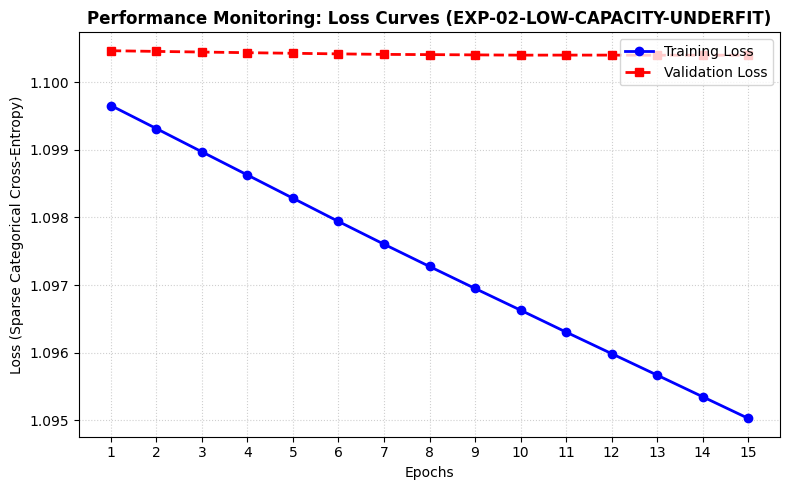

In [17]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, CONFIG["epochs"] + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

**Line-by-Line Explanation**

1.   `train_losses` / `val_losses` - pulled from this run's `history`, not EXP-01's
1.   `plt.plot(...)` calls - identical styling to Cell 7, so the two charts are visually comparable side by side
1.   `plt.title(f'... ({CONFIG["run_id"]})')` - automatically labels this chart "EXP-02-LOW-CAPACITY-UNDERFIT" since it reads from CONFIG, so there's no risk of mislabeling which experiment this plot belongs to

**How to read this one specifically:** if both lines stay flat and close together near the top of the y-axis (high loss, little movement) - that confirms underfitting. If it instead looks similar to EXP-01's diverging curves, the underfitting attempt didn't work as intended and it's worth noting that in your report as an unexpected result.

## CELL 7.2: Generate Loss Curves Chart — EXP-03
**Purpose**
Visualize EXP-03's training vs. validation loss to confirm and characterize the overfitting.

**Input**
`history` from Cell 6.2, `CONFIG["epochs"]` from Cell 3.2

**Output**
A loss curve chart labeled EXP-03, for visual comparison against EXP-01 and EXP-02 in your report

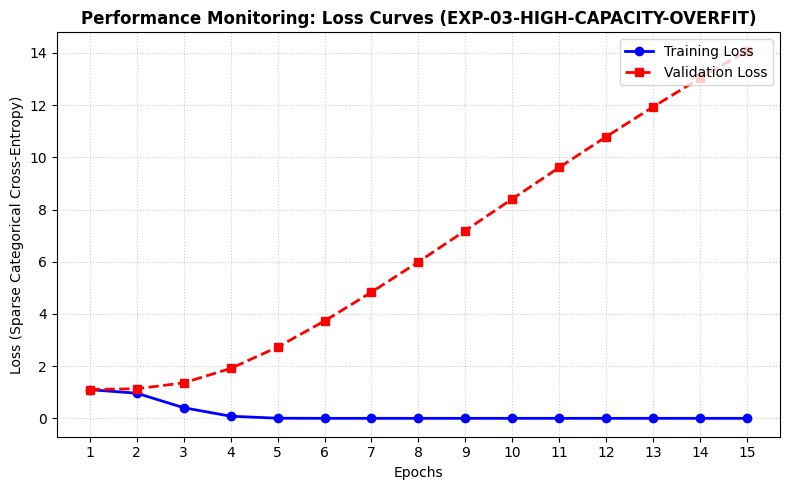

In [23]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, CONFIG["epochs"] + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

**Line-by-Line Explanation**

1.   `train_losses` / `val_losses` - pulled from this run's `history`
1.   `plt.plot(...)` calls - identical styling to prior charts, so all three plots stay visually comparable
1.   `plt.title(f'... ({CONFIG["run_id"]})')` - automatically labels this chart "EXP-03-HIGH-CAPACITY-OVERFIT" from CONFIG

**How to read this one specifically:** look for training loss dropping fast (possibly with some jitter, given the large learning rate) while validation loss rises or diverges - if the gap between the two lines is wider than EXP-01's, that confirms the higher capacity plus zero dropout made overfitting worse, as expected.

## CELL 7.3: Generate Loss Curves Chart — EXP-04
**Purpose**
Visualize EXP-04's training vs. validation loss to evaluate whether dropout controlled the overfitting.

**Input**
`history` from Cell 6.3, `CONFIG["epochs"]` from Cell 3.3

**Output**
A loss curve chart labeled EXP-04, for direct visual comparison against EXP-03's plot

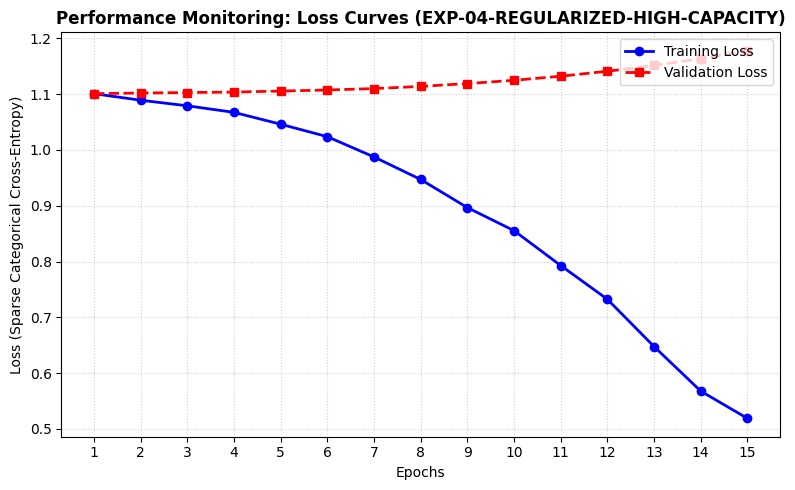

In [29]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, CONFIG["epochs"] + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

**Line-by-Line Explanation**

1.   `train_losses` / `val_losses` - pulled from this run's `history`
1.   `plt.plot(...)` calls - identical styling to prior charts
1.   `plt.title(f'... ({CONFIG["run_id"]})')` - automatically labels this chart "EXP-04-REGULARIZED-HIGH-CAPACITY" from CONFIG

**How to read this one specifically:** compare the gap between training and validation loss here against EXP-03's plot - if dropout worked, the gap should be much smaller, and validation loss should not explode into double digits the way it did in EXP-03.

## CELL 7.4: Generate Loss Curves Chart — EXP-05A
**Purpose**
Visualize EXP-05A's training vs. validation loss, including where Early Stopping halted training.

**Input**
`history` from Cell 6.4 (length may be less than 30 epochs)

**Output**
A loss curve chart labeled EXP-05A, showing the actual number of epochs that ran

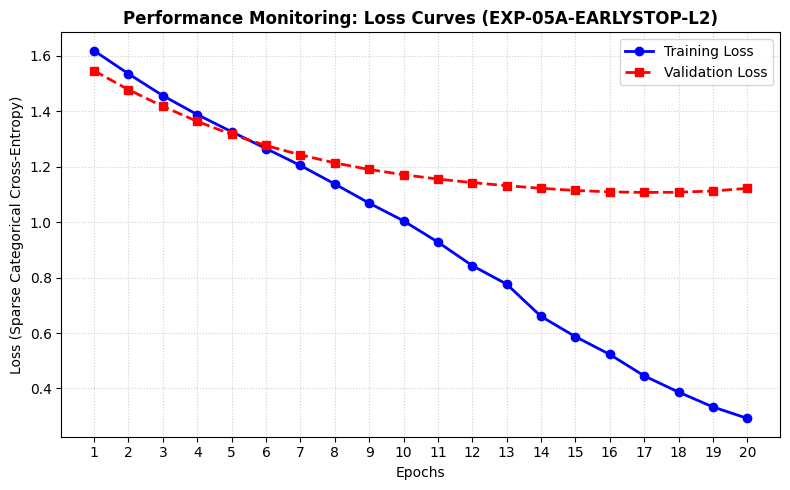

In [40]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

**Line-by-Line Explanation**

1.   `train_losses` / `val_losses` - pulled from this run's `history`; length depends on when Early Stopping fired, not fixed at 30
1.   `epochs_range = range(1, len(train_losses) + 1)` - unlike prior cells, this uses the *actual* number of epochs run (from `history`), not `CONFIG["epochs"]`, since Early Stopping may have cut training short
1.   `plt.plot(...)` calls - identical styling to prior charts
1.   `plt.title(...)` - labels this chart "EXP-05A-EARLYSTOP-L2" from CONFIG

**How to read this one specifically:** the x-axis will likely be shorter than 30 - that's Early Stopping working correctly. Compare the shape of the curves against EXP-04's: if L2 + Early Stopping worked, validation loss should flatten out or dip rather than climbing continuously like EXP-01/EXP-04 did.

## CELL 7.5: Generate Loss Curves Chart — EXP-05B
**Purpose**
Visualize EXP-05B's training vs. validation loss for direct comparison against EXP-05A's plot.

**Input**
`history` from Cell 6.5

**Output**
A loss curve chart labeled EXP-05B

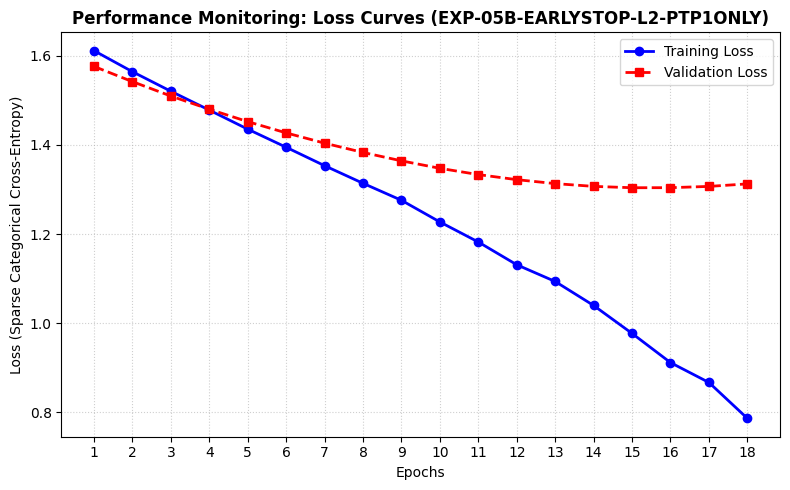

In [58]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

**Line-by-Line Explanation**

1.   `train_losses` / `val_losses` - pulled from this run's `history`
1.   `epochs_range = range(1, len(train_losses) + 1)` - uses actual epochs run, since Early Stopping may cut this short too
1.   `plt.title(...)` - labels this chart "EXP-05B-EARLYSTOP-L2-PTP1ONLY" from CONFIG

**How to read this one specifically:** compare the shape and final loss values directly against EXP-05A's chart - similar curves with similar final numbers means the dataset size mattered less than expected; a noticeably worse curve here confirms the expanded dataset was doing real work in EXP-05A.

## EXP-02: Low Capacity & Too Small LR (Induce Underfitting)
Combines Config → Architecture → Compile → Train → Loss Curve into a single cell for EXP-02. Uses `hidden_dim: 16` and `learning_rate: 0.0001` to deliberately starve the model of capacity and step size, testing whether it underfits — both training and validation loss should stay high and barely move across the 15 epochs, unlike EXP-01's clear overfitting pattern.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- Starting Training Run: EXP-02-LOW-CAPACITY-UNDERFIT ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2903 - loss: 1.0977 - val_accuracy: 0.1429 - val_loss: 1.0992
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.2903 - loss: 1.0973 - val_accuracy: 0.1429 - val_loss: 1.0992
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3226 - loss: 1.0970 - val_accuracy: 0.1429 - val_loss: 1.0992
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.3548 - loss: 1.0967 - val_accuracy: 0.1429 - val_loss: 1.0992
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.3871 - loss: 1.0964 - val_accuracy: 0.1429 - val_loss: 1.0993
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.3871 - loss: 1.0961 - val_accuracy: 0.1429 - val_loss: 1.0993
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.4194 - loss: 1.0958 - val_accuracy: 0.1429 - val_loss: 1.0993
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy:

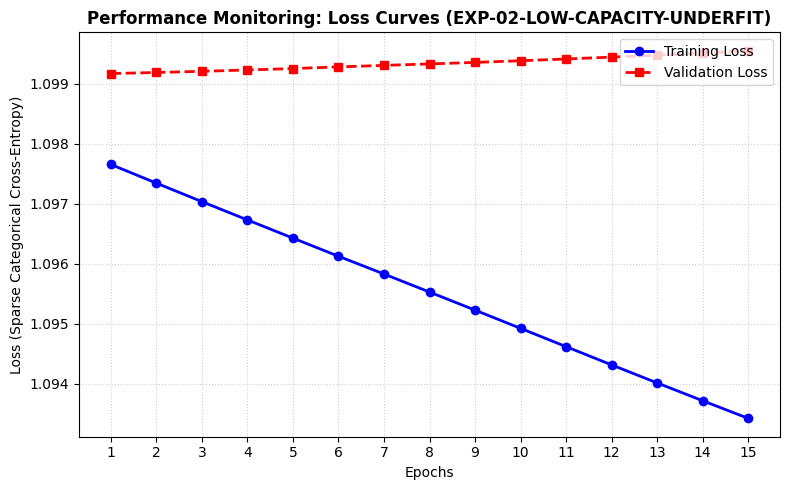

In [18]:
# ============================================
# EXP-02: LOW CAPACITY & TOO SMALL LR (Induce Underfitting)
# ============================================

# --- Config ---
CONFIG = {
    "run_id": "EXP-02-LOW-CAPACITY-UNDERFIT",
    "embed_dim": 32,
    "hidden_dim": 16,
    "learning_rate": 0.0001,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.0
}

# --- Architecture ---
model = Sequential()
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))

# --- Optimizer & Compilation ---
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

# --- Train & Evaluate ---
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

# --- Loss Curve ---
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, CONFIG["epochs"] + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

## EXP-03: High Capacity & No Regularization (Induce Overfitting)
Combines Config → Architecture → Compile → Train → Loss Curve into a single cell for EXP-03. Uses `hidden_dim: 256`, `learning_rate: 0.05`, and `dropout_rate: 0.0` to maximize model capacity while removing the only regularization mechanism, testing whether this produces overfitting more severe than EXP-01's baseline.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- Starting Training Run: EXP-03-HIGH-CAPACITY-OVERFIT ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3548 - loss: 1.0984 - val_accuracy: 0.4286 - val_loss: 1.1077
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.8387 - loss: 0.9769 - val_accuracy: 0.2857 - val_loss: 1.2107
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 1.0000 - loss: 0.3829 - val_accuracy: 0.1429 - val_loss: 1.3697
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 1.0000 - loss: 0.0370 - val_accuracy: 0.0000e+00 - val_loss: 1.7892
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 1.0000 - loss: 9.6035e-04 - val_accuracy: 0.0000e+00 - val_loss: 2.4396
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 1.0000 - loss: 1.2067e-05 - val_accuracy: 0.1429 - val_loss: 3.2610
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step - accuracy: 1.0000 - loss: 8.4600e-08 - val_accuracy: 0.1429 - val_loss: 4.1921
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

=== EXP LOG ENTRY ===
ID: EXP-03-HIGH-CAPACITY-OVERFIT | LR: 0.05 | Hidden: 256 | Dropout: 0.0 | Final Val Loss: 12.0784 | Final Val F1: 0.0000


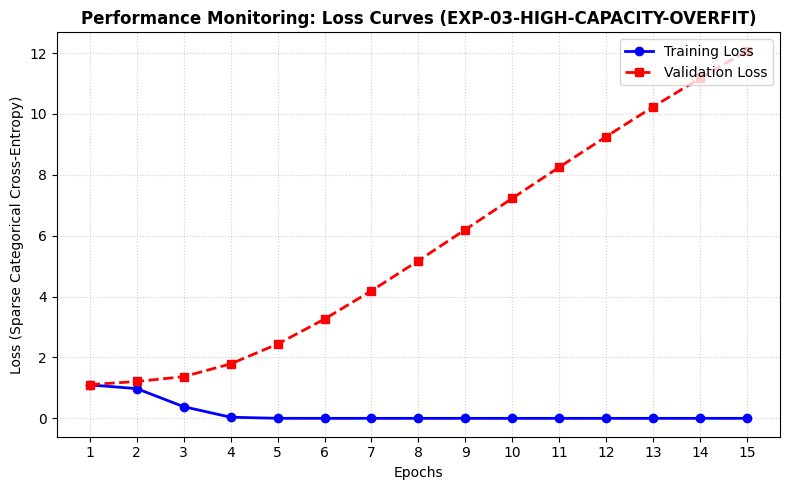

In [24]:
# ============================================
# EXP-03: HIGH CAPACITY & NO REGULARIZATION (Induce Overfitting)
# ============================================

# --- Config ---
CONFIG = {
    "run_id": "EXP-03-HIGH-CAPACITY-OVERFIT",
    "embed_dim": 32,
    "hidden_dim": 256,
    "learning_rate": 0.05,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.0
}

# --- Architecture ---
model = Sequential()
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))

# --- Optimizer & Compilation ---
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

# --- Train & Evaluate ---
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

# --- Loss Curve ---
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, CONFIG["epochs"] + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

## EXP-04: Regularized High Capacity (Introduce Dropout)
Combines Config → Architecture → Compile → Train → Loss Curve into a single cell for EXP-04. Uses `hidden_dim: 128` and `dropout_rate: 0.4` with the baseline learning rate (0.005) — the only major change from EXP-03 is dropout being switched on, isolating regularization as the variable being tested against EXP-03's extreme overfitting.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_7      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- Starting Training Run: EXP-04-REGULARIZED-HIGH-CAPACITY ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1290 - loss: 1.1009 - val_accuracy: 0.2857 - val_loss: 1.1008
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5806 - loss: 1.0896 - val_accuracy: 0.2857 - val_loss: 1.1016
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6452 - loss: 1.0790 - val_accuracy: 0.2857 - val_loss: 1.1031
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7097 - loss: 1.0604 - val_accuracy: 0.2857 - val_loss: 1.1048
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7097 - loss: 1.0434 - val_accuracy: 0.2857 - val_loss: 1.1079
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7742 - loss: 1.0251 - val_accuracy: 0.2857 - val_loss: 1.1118
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7742 - loss: 0.9903 - val_accuracy: 0.2857 - val_loss: 1.1159
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accur

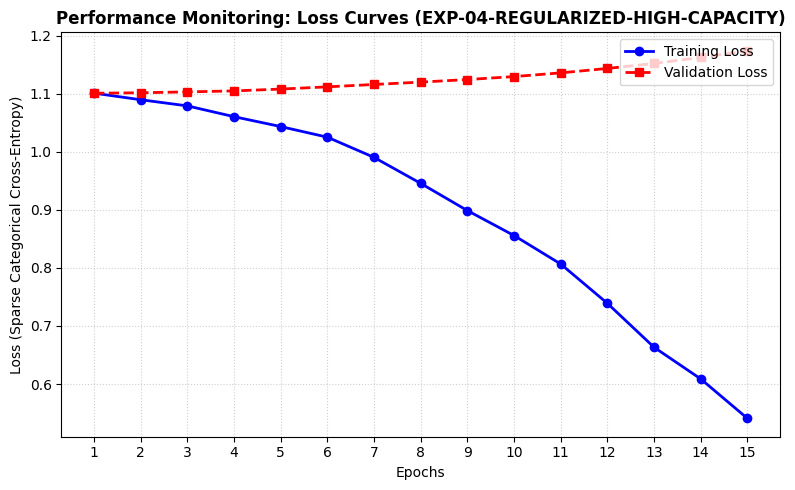

In [30]:
# ============================================
# EXP-04: REGULARIZED HIGH CAPACITY (Introduce Dropout)
# ============================================

# --- Config ---
CONFIG = {
    "run_id": "EXP-04-REGULARIZED-HIGH-CAPACITY",
    "embed_dim": 32,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.4
}

# --- Architecture ---
model = Sequential()
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))

# --- Optimizer & Compilation ---
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

# --- Train & Evaluate ---
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

# --- Loss Curve ---
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, CONFIG["epochs"] + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

## Load & Combine Datasets (for EXP-05 Data Augmentation)
Loads both the PT-P1 dataset and the instructor's sample_dataset.csv, combines and shuffles them into one larger training pool, then rebuilds the vocabulary and train/val/test split from this expanded dataset. Run this once, before any EXP-05 config/architecture/train cells — everything downstream will use these larger `X_train`/`X_val`/`X_test` automatically.

In [46]:
# ============================================
# DATA EXPANSION: COMBINE PT-P1 + SAMPLE DATASET (for EXP-05)
# ============================================

CSV_FILEPATH = '/content/drive/MyDrive/NN Training/PT-P1_Dataset.csv'  # adjust path if needed
SAMPLE_CSV_FILEPATH = '/content/drive/MyDrive/NN Training/sample_dataset.csv'  # adjust path to match your Drive

# Load both datasets
df_ptp1 = pd.read_csv(CSV_FILEPATH)
df_sample = pd.read_csv(SAMPLE_CSV_FILEPATH)

# Keep only text/label columns from the sample dataset
df_sample = df_sample[['text', 'label']]

# Combine and shuffle
df_combined = pd.concat([df_ptp1, df_sample], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"PT-P1 rows: {len(df_ptp1)}")
print(f"Sample dataset rows: {len(df_sample)}")
print(f"Combined total rows: {len(df_combined)}")
print(f"\nClass balance after combining:")
print(df_combined['label'].value_counts().sort_index())

# Rebuild vocab and encode text using the COMBINED dataset
vocab = build_vocab(df_combined['text'].tolist(), MAX_VOCAB_SIZE)
encoded_texts = [text_to_sequence(txt, vocab, MAX_LEN) for txt in df_combined['text']]

X_data = np.array(encoded_texts)
y_data = np.array(df_combined['label'].values)
num_classes = len(np.unique(y_data))

# Re-split using the combined, larger dataset (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"\nNew training set size: {len(X_train)} (up from {int(len(df_ptp1)*0.7)} with PT-P1 alone)")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/NN Training/PT-P1_Dataset.csv'

## EXP-05A: Early Stopping + L2 Regularization
Combines Config → Architecture (with L2 weight decay) → Compile → Train (with Early Stopping) → Loss Curve into a single cell for EXP-05A. Builds on EXP-04's architecture (hidden_dim 128, dropout 0.4) and adds L2 regularization plus an Early Stopping callback, trained on the expanded dataset from Cell 2.1. Tests whether these techniques — unavailable in the no-code tool — can finally close the gap with the PT-P1 benchmark.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- Starting Training Run: EXP-05A-EARLYSTOP-L2 ---
Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 648ms/step - accuracy: 0.3333 - loss: 1.6172 - val_accuracy: 0.6667 - val_loss: 1.5415
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5000 - loss: 1.5320 - val_accuracy: 0.4444 - val_loss: 1.4712
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4286 - loss: 1.4566 - val_accuracy: 0.4444 - val_loss: 1.4094
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3333 - loss: 1.3889 - val_accuracy: 0.4444 - val_loss: 1.3545
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3571 - loss: 1.3285 - val_accuracy: 0.4444 - val_loss: 1.3070
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4048 - loss: 1.2678 - val_accuracy: 0.4444 - val_loss: 1.2661
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5714 - loss: 1.2161 - val_accuracy: 0.4444 - val_loss: 1.2309
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6429 - lo

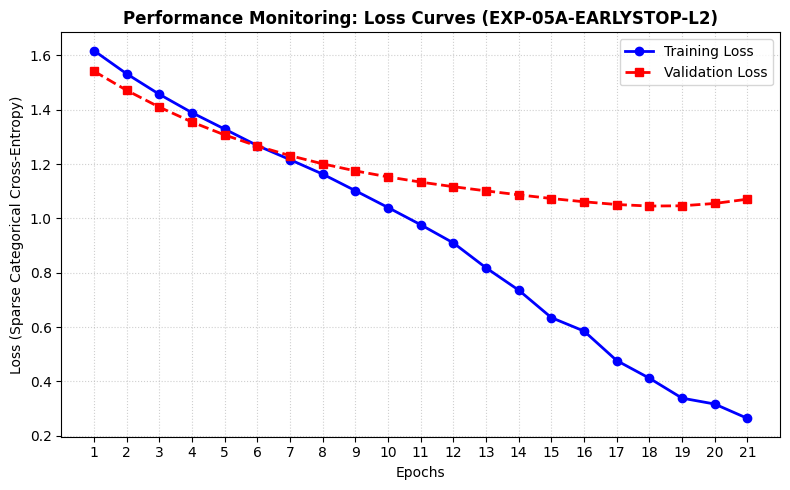

In [41]:
# ============================================
# EXP-05A: EARLY STOPPING + L2 REGULARIZATION
# ============================================

from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# --- Config ---
CONFIG = {
    "run_id": "EXP-05A-EARLYSTOP-L2",
    "embed_dim": 32,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 30,
    "optimizer_type": "Adam",
    "dropout_rate": 0.4,
    "l2_lambda": 0.01,
    "early_stop_patience": 3
}

# --- Architecture (with L2 weight decay) ---
model = Sequential()
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu', kernel_regularizer=l2(CONFIG["l2_lambda"])))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))

# --- Optimizer & Compilation ---
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

# --- Train & Evaluate (with Early Stopping) ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=CONFIG["early_stop_patience"],
    restore_best_weights=True
)

print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]
epochs_ran = len(history.history['loss'])

print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | L2: {CONFIG['l2_lambda']} | Epochs Ran: {epochs_ran}/{CONFIG['epochs']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

# --- Loss Curve ---
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

## EXP-05B: Early Stopping + L2 Regularization (PT-P1 Only, No Data Expansion)
Same architecture and regularization as EXP-05A (L2 + dropout + Early Stopping), but trained on the original 45-row PT-P1 dataset instead of the expanded combined dataset. Isolates whether EXP-05A's strong result came from the regularization techniques, the expanded data, or both — directly answers Debrief Question 3 (data volume/diversity vs. architectural capacity).

Training on PT-P1 only: 31 train samples (vs. EXP-05A's combined dataset)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_13     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- Starting Training Run: EXP-05B-EARLYSTOP-L2-PTP1ONLY ---
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.4194 - loss: 1.6078 - val_accuracy: 0.4286 - val_loss: 1.5694
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5806 - loss: 1.5608 - val_accuracy: 0.2857 - val_loss: 1.5333
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7742 - loss: 1.5160 - val_accuracy: 0.2857 - val_loss: 1.5002
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7097 - loss: 1.4688 - val_accuracy: 0.2857 - val_loss: 1.4692
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6774 - loss: 1.4253 - val_accuracy: 0.2857 - val_loss: 1.4406
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7419 - loss: 1.3837 - val_accuracy: 0.2857 - val_loss: 1.4148
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8065 - loss: 1.3402 - val_accuracy: 0.2857 - val_loss: 1.3912
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.741

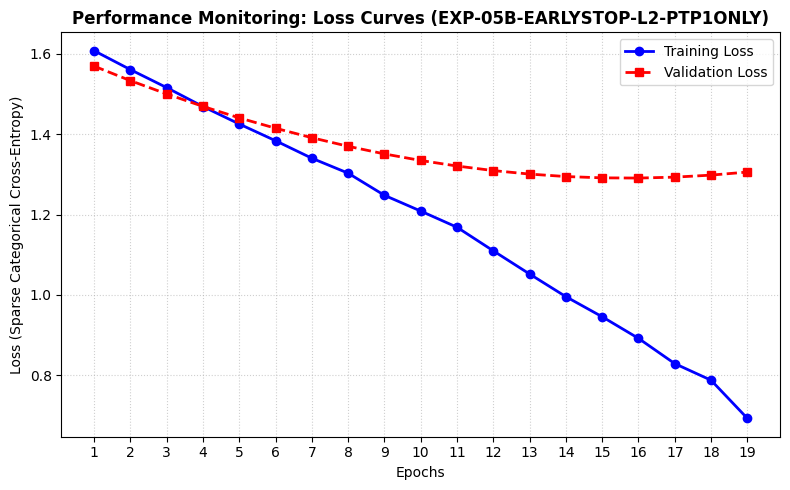

In [60]:
# ============================================
# EXP-05B: EARLY STOPPING + L2 (PT-P1 ONLY — NO DATA EXPANSION)
# ============================================

from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# --- Reload PT-P1-only dataset (undo Cell 2.1's expansion for this run) ---
CSV_FILEPATH = '/content/drive/MyDrive/NN_Training/PT-P1_Dataset.csv'
df_ptp1_only = pd.read_csv(CSV_FILEPATH)

vocab = build_vocab(df_ptp1_only['text'].tolist(), MAX_VOCAB_SIZE)
encoded_texts = [text_to_sequence(txt, vocab, MAX_LEN) for txt in df_ptp1_only['text']]

X_data = np.array(encoded_texts)
y_data = np.array(df_ptp1_only['label'].values)
num_classes = len(np.unique(y_data))

X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training on PT-P1 only: {len(X_train)} train samples (vs. EXP-05A's combined dataset)")

# --- Config ---
CONFIG = {
    "run_id": "EXP-05B-EARLYSTOP-L2-PTP1ONLY",
    "embed_dim": 32,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 30,
    "optimizer_type": "Adam",
    "dropout_rate": 0.4,
    "l2_lambda": 0.01,
    "early_stop_patience": 3
}

# --- Architecture (with L2 weight decay) ---
model = Sequential()
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu', kernel_regularizer=l2(CONFIG["l2_lambda"])))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))

# --- Optimizer & Compilation ---
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

# --- Train & Evaluate (with Early Stopping) ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=CONFIG["early_stop_patience"],
    restore_best_weights=True
)

print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]
epochs_ran = len(history.history['loss'])

print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | L2: {CONFIG['l2_lambda']} | Epochs Ran: {epochs_ran}/{CONFIG['epochs']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

# --- Loss Curve ---
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

#The full untampered source code

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- Starting Training Run: EXP-01-KERAS-BASELINE ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2581 - loss: 1.0994 - val_accuracy: 0.1429 - val_loss: 1.0998
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7097 - loss: 1.0886 - val_accuracy: 0.2857 - val_loss: 1.1018
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7097 - loss: 1.0753 - val_accuracy: 0.2857 - val_loss: 1.1037
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7097 - loss: 1.0590 - val_accuracy: 0.2857 - val_loss: 1.1055
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8065 - loss: 1.0389 - val_accuracy: 0.2857 - val_loss: 1.1074
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9355 - loss: 1.0145 - val_accuracy: 0.2857 - val_loss: 1.1094
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9032 - loss: 0.9825 - val_accuracy: 0.2857 - val_loss: 1.1121
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9677 - loss

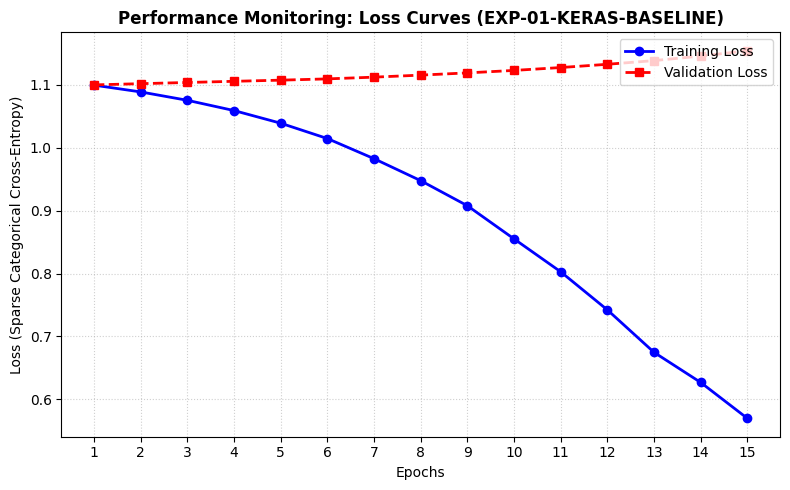

In [12]:
# ============================================
# SETUP
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from collections import Counter
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================
# 1. LOAD & PREPROCESS CSV DATA
# ============================================
CSV_FILEPATH = '/content/drive/MyDrive/NN_Training/PT-P1_Dataset.csv'
MAX_LEN = 20            # Fixed sequence length (padded/truncated)
MAX_VOCAB_SIZE = 1000   # Vocabulary size limit

# Load CSV
df = pd.read_csv(CSV_FILEPATH)

# Basic Tokenizer & Vocabulary Builder
def build_vocab(texts, max_vocab_size):
    words = [word.lower() for text in texts for word in str(text).split()]
    word_counts = Counter(words)
    # Reserve index 0 for padding (<PAD>) and 1 for unknown tokens (<UNK>)
    most_common = word_counts.most_common(max_vocab_size - 2)
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

def text_to_sequence(text, vocab, max_len):
    tokens = str(text).lower().split()
    seq = [vocab.get(token, 1) for token in tokens]
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))  # Pad with 0
    else:
        seq = seq[:max_len]                # Truncate
    return seq

# Build vocab and encode text
vocab = build_vocab(df['text'].tolist(), MAX_VOCAB_SIZE)
encoded_texts = [text_to_sequence(txt, vocab, MAX_LEN) for txt in df['text']]

X_data = np.array(encoded_texts)
y_data = np.array(df['label'].values)
num_classes = len(np.unique(y_data))

# Dataset Partitioning (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# ============================================
# 2. HYPERPARAMETER CONFIGURATION
# ============================================
CONFIG = {
    "run_id": "EXP-01-KERAS-BASELINE",
    "embed_dim": 32,
    "hidden_dim": 64,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.1
}

# ============================================
# 3. KERAS SEQUENTIAL ARCHITECTURE
# ============================================
model = Sequential()

# Embedding Layer (Pillar 1: Architecture)
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))

# Global Average Pooling across token sequence dimension
model.add(GlobalAveragePooling1D())

# First Hidden Layer
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))

# Regularization Layer (Pillar 3: Regularization)
model.add(Dropout(CONFIG["dropout_rate"]))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

# ============================================
# 4. OPTIMIZER & COMPILATION
# ============================================
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

# Configure loss function, optimizer engine, and evaluation metrics
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

model.summary()

# ============================================
# 5. THE OPERATIONAL LOOP (FIT & EVALUATE)
# ============================================
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Compute final validation predictions for F1-Score calculation
val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

# Final Log Output summary for Excel logging
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | Dropout: {CONFIG['dropout_rate']} | Final Val Loss: {val_loss:.4f} | Final Val F1: {val_f1:.4f}")

# ============================================
# 6. GENERATE LOSS CURVES CHART
# ============================================
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, CONFIG["epochs"] + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()